In [2]:
# 0. Imports y utilidades
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns          # opcional si quieres estilo; no es obligatorio
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    accuracy_score, f1_score, precision_score, recall_score
)
from math import sqrt

# Ajustes estéticos globales (opcional)
sns.set(context="notebook", style="whitegrid")


In [3]:
# 1. Generar dataset
X, y = make_moons(n_samples=1000, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [4]:
# 2. Escalado
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 3. Entrenar regresión logística
clf = LogisticRegression(solver='lbfgs', max_iter=1000)
clf.fit(X_train_s, y_train)


LogisticRegression(max_iter=1000)

In [5]:
# 4. Probabilidades y predicciones con umbral 0.5
y_prob = clf.predict_proba(X_test_s)[:, 1]
y_pred_05 = (y_prob >= 0.5).astype(int)

# 5. Matriz de confusión (umbral 0.5)
# --> usar labels=[0,1] para forzar forma 2x2 y evitar errores si falta alguna clase
cm_05 = confusion_matrix(y_test, y_pred_05, labels=[0,1])
tn, fp, fn, tp = cm_05.ravel()
print("Matriz confusión (th=0.5):")
print(cm_05)


Matriz confusión (th=0.5):
[[137  13]
 [ 22 128]]


In [7]:
# 6. ROC y AUC
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 7. Curva Precision-Recall
prec, rec, pr_thresh = precision_recall_curve(y_test, y_prob)

print(f"AUC (ROC): {roc_auc:.4f}")


AUC (ROC): 0.9492


In [8]:
# 8. Métricas a través de umbrales (0..1) - manejo robusto
thresholds = np.linspace(0.0, 1.0, 501)
metrics = []
for th in thresholds:
    yp = (y_prob >= th).astype(int)
    # forzar 2x2 usando labels evita shape mismatch
    cm = confusion_matrix(y_test, yp, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    # métricas con manejo de divisiones por cero
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0.0        # Sensitivity (SNS)
    spec_val = tn / (tn + fp) if (tn + fp) > 0 else 0.0       # Specificity (SPC)
    prec_val = tp / (tp + fp) if (tp + fp) > 0 else 0.0       # Precision (PRC)
    npv_val = tn / (tn + fn) if (tn + fn) > 0 else 0.0        # NPV
    acc_val = (tp + tn) / (tp + tn + fp + fn)
    f1_val = (2 * prec_val * tpr_val) / (prec_val + tpr_val) if (prec_val + tpr_val) > 0 else 0.0
    gm_val = sqrt(tpr_val * spec_val) if (tpr_val >= 0 and spec_val >= 0) else 0.0
    metrics.append((th, tpr_val, spec_val, prec_val, npv_val, acc_val, f1_val, gm_val))

metrics_df = pd.DataFrame(metrics, columns=['threshold','TPR','SPEC','PREC','NPV','ACC','F1','GM'])


In [9]:
# 9. Elegir umbrales óptimos (máximo F1 y máximo GM)
best_f1_row = metrics_df.loc[metrics_df['F1'].idxmax()]
best_gm_row = metrics_df.loc[metrics_df['GM'].idxmax()]

# Predicciones con umbrales óptimos (asegurar que usamos float->comparación)
y_pred_best_f1 = (y_prob >= float(best_f1_row['threshold'])).astype(int)
y_pred_best_gm = (y_prob >= float(best_gm_row['threshold'])).astype(int)
cm_best_f1 = confusion_matrix(y_test, y_pred_best_f1, labels=[0,1])
cm_best_gm = confusion_matrix(y_test, y_pred_best_gm, labels=[0,1])

print("Mejor umbral según F1:", best_f1_row['threshold'])
print("Mejor umbral según GM:", best_gm_row['threshold'])
print("Matriz (best F1):\n", cm_best_f1)
print("Matriz (best GM):\n", cm_best_gm)


Mejor umbral según F1: 0.516
Mejor umbral según GM: 0.516
Matriz (best F1):
 [[138  12]
 [ 22 128]]
Matriz (best GM):
 [[138  12]
 [ 22 128]]


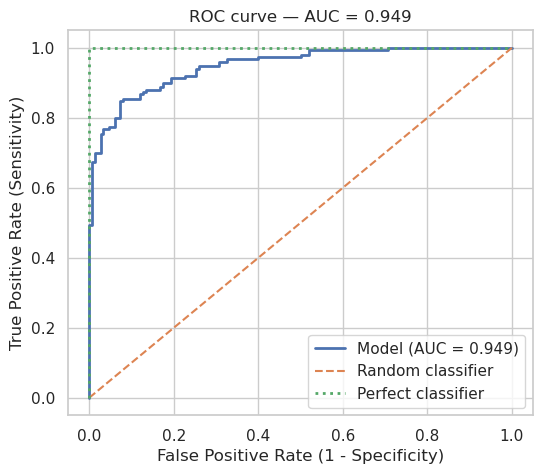

In [10]:
# 11a. ROC plot (modelo actual) + línea de un modelo perfecto
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'Model (AUC = {roc_auc:.3f})')
# Curva de referencia aleatoria
plt.plot([0,1], [0,1], linestyle='--', label='Random classifier')
# Curva de modelo perfecto: subir a TPR=1 en FPR=0 (vertical en x=0 luego horizontal en y=1)
# para visualizarlo: puntos (0,0) -> (0,1) -> (1,1)
plt.plot([0, 0, 1], [0, 1, 1], linestyle=':', linewidth=2, label='Perfect classifier')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC curve — AUC = {roc_auc:.3f}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


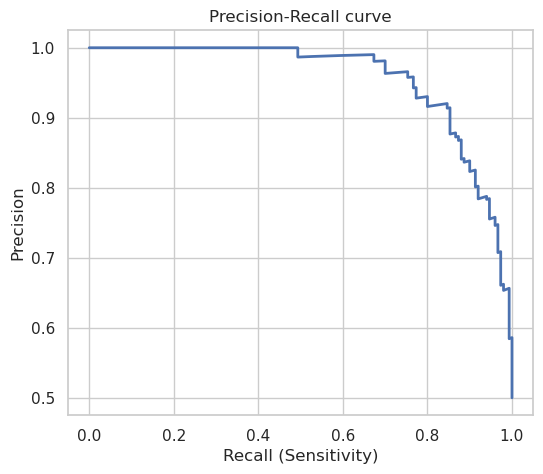

In [11]:
plt.figure(figsize=(6,5))
plt.plot(rec, prec, lw=2)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.grid(True)
plt.show()


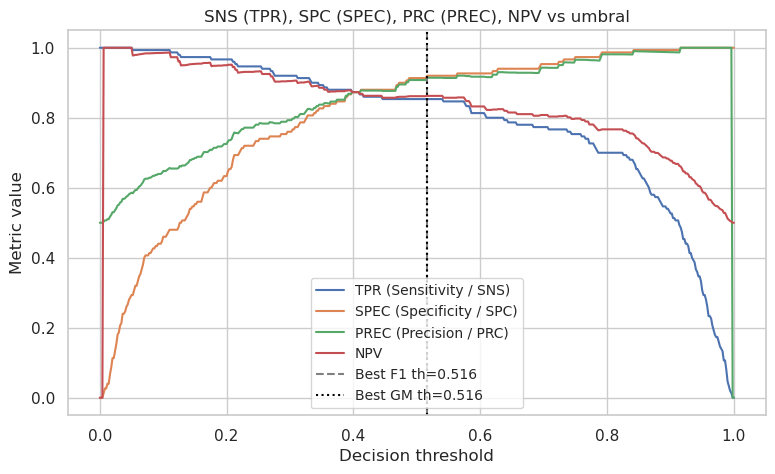

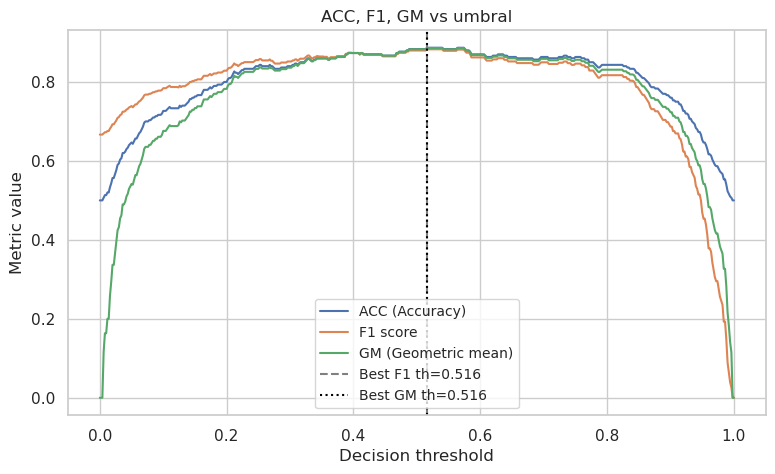

In [12]:
# 12a. Plot A: TPR (SNS), SPEC (SPC), PREC (PRC), NPV vs threshold
plt.figure(figsize=(9,5))
plt.plot(metrics_df['threshold'], metrics_df['TPR'], label='TPR (Sensitivity / SNS)')
plt.plot(metrics_df['threshold'], metrics_df['SPEC'], label='SPEC (Specificity / SPC)')
plt.plot(metrics_df['threshold'], metrics_df['PREC'], label='PREC (Precision / PRC)')
plt.plot(metrics_df['threshold'], metrics_df['NPV'], label='NPV')
plt.axvline(best_f1_row['threshold'], color='gray', linestyle='--', label=f'Best F1 th={best_f1_row["threshold"]:.3f}')
plt.axvline(best_gm_row['threshold'], color='black', linestyle=':', label=f'Best GM th={best_gm_row["threshold"]:.3f}')
plt.xlabel('Decision threshold')
plt.ylabel('Metric value')
plt.title('SNS (TPR), SPC (SPEC), PRC (PREC), NPV vs umbral')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.show()

# 12b. Plot B: ACC, F1, GM vs threshold
plt.figure(figsize=(9,5))
plt.plot(metrics_df['threshold'], metrics_df['ACC'], label='ACC (Accuracy)')
plt.plot(metrics_df['threshold'], metrics_df['F1'], label='F1 score')
plt.plot(metrics_df['threshold'], metrics_df['GM'], label='GM (Geometric mean)')
plt.axvline(best_f1_row['threshold'], color='gray', linestyle='--', label=f'Best F1 th={best_f1_row["threshold"]:.3f}')
plt.axvline(best_gm_row['threshold'], color='black', linestyle=':', label=f'Best GM th={best_gm_row["threshold"]:.3f}')
plt.xlabel('Decision threshold')
plt.ylabel('Metric value')
plt.title('ACC, F1, GM vs umbral')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.show()


In [13]:
# Mostrar resumen simple (sin dependencias extra)
summary = pd.DataFrame({
    'criterion':['AUC','best_F1_threshold','best_GM_threshold'],
    'value':[roc_auc, float(best_f1_row['threshold']), float(best_gm_row['threshold'])]
})
print(summary)

# Mostrar las primeras 15 filas de metrics_df
display(metrics_df.head(15))   # en notebooks IPython esto funciona; si no, usa print(metrics_df.head(15))


           criterion     value
0                AUC  0.949156
1  best_F1_threshold  0.516000
2  best_GM_threshold  0.516000


,threshold,TPR,SPEC,PREC,NPV,ACC,F1,GM
0,0.000,1.0,0.000000,0.500000,0.0,0.500000,0.666667,0.000000
1,0.002,1.0,0.000000,0.500000,0.0,0.500000,0.666667,0.000000
2,0.004,1.0,0.000000,0.500000,0.0,0.500000,0.666667,0.000000
3,0.006,1.0,0.013333,0.503356,1.0,0.506667,0.669643,0.115470
4,0.008,1.0,0.026667,0.506757,1.0,0.513333,0.672646,0.163299
5,0.010,1.0,0.026667,0.506757,1.0,0.513333,0.672646,0.163299
6,0.012,1.0,0.040000,0.510204,1.0,0.520000,0.675676,0.200000
7,0.014,1.0,0.040000,0.510204,1.0,0.520000,0.675676,0.200000
8,0.016,1.0,0.066667,0.517241,1.0,0.533333,0.681818,0.258199
9,0.018,1.0,0.086667,0.522648,1.0,0.543333,0.686499,0.294392
